In [1]:
import os
import math
import time
import random
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from torchvision.transforms.functional import to_pil_image, resize
from PIL import Image, ImageDraw
from torchvision.transforms import InterpolationMode

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = True
DATA_DIR = "./data"

BATCH_SIZE = 64  # ResNet тяжелее, чем SimpleCNN
EPOCHS_HEAD = 4 if FAST_MODE else 8
EPOCHS_FT   = 4 if FAST_MODE else 8
EPOCHS = 5 if FAST_MODE else 12

Device: cpu


In [3]:
def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

weights: ResNet18_Weights.IMAGENET1K_V1


In [4]:
# mean/std для нормализации (стандартные ImageNet)
STL10_MEAN = (0.485, 0.456, 0.406)
STL10_STD  = (0.229, 0.224, 0.225)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

def load_stl10_tl(data_dir: str = DATA_DIR, val_split: float = 0.2, seed: int = 42):
    """
    Загрузка STL10 с разделением train на train/val.
    val_split: доля val в train (0.2 = 80/20)
    """
    # Фиксируем seed для воспроизводимости
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Загружаем train с аугментациями и без
    ds_train_aug  = torchvision.datasets.STL10(root=data_dir, split='train', 
                                              download=True, transform=train_tf)
    ds_train_eval = torchvision.datasets.STL10(root=data_dir, split='train', 
                                              download=True, transform=eval_tf)
    
    # Загружаем test
    ds_test = torchvision.datasets.STL10(root=data_dir, split='test', 
                                        download=True, transform=eval_tf)
    
    # Создаем индексы для разделения train (5000 образцов)
    n_train = len(ds_train_aug)
    n_val = int(n_train * val_split)
    n_train_final = n_train - n_val
    
    indices = list(range(n_train))
    np.random.shuffle(indices)
    
    train_idx = indices[:n_train_final]
    val_idx = indices[n_train_final:]
    
    # Создаем подмножества
    ds_train_aug_final = Subset(ds_train_aug, train_idx)
    ds_train_eval_final = Subset(ds_train_eval, train_idx)
    ds_val = Subset(ds_train_eval, val_idx)
    
    print(f"Train full: {n_train}")
    print(f"Train final: {len(ds_train_aug_final)} (80%)")
    print(f"Val: {len(ds_val)} (20%)")
    print(f"Test: {len(ds_test)}")
    
    return ds_train_aug_final, ds_train_eval_final, ds_val, ds_test

# Загружаем данные
ds_train_aug, ds_train_eval, ds_val, ds_test = load_stl10_tl()
class_names = ds_train_aug.dataset.classes
print("Class names:", class_names)


Train full: 5000
Train final: 4000 (80%)
Val: 1000 (20%)
Test: 8000
Class names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [5]:
def make_loaders_tl(
    ds_train_aug,
    ds_train_eval,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    n_total = len(ds_train_aug)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train = Subset(ds_train_aug, train_idx)
    ds_val   = Subset(ds_train_eval, val_idx)

    if fast_mode:
        train_idx2 = rng.choice(len(ds_train), size=min(4000, len(ds_train)), replace=False)
        val_idx2   = rng.choice(len(ds_val), size=min(1000, len(ds_val)), replace=False)
        test_idx2  = rng.choice(len(ds_test), size=min(1000, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx2)
        ds_val   = Subset(ds_val, val_idx2)
        ds_test_small = Subset(ds_test, test_idx2)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders_tl(ds_train_aug, ds_train_eval, ds_test)

x, y = next(iter(train_loader))
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

C:\Users\Mi\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


x: torch.Size([64, 3, 224, 224]) torch.float32
y: torch.Size([64]) torch.int64


In [6]:
# 2) Конфигурация
@dataclass
class RunConfig:
    data_dir: str = "./data"
    fast_mode: bool = True
    n_show: int = 4                 # сколько примеров визуализируем
    score_thr: float = 0.6          # порог по score для предсказаний
    iou_thr: float = 0.5            # порог IoU для TP/FP/FN
    model_name: str = "fasterrcnn_mobilenet_v3_large_fpn"  # быстрее на CPU
    # варианты: "fasterrcnn_resnet50_fpn_v2", "retinanet_resnet50_fpn_v2", ...

cfg = RunConfig()
cfg

RunConfig(data_dir='./data', fast_mode=True, n_show=4, score_thr=0.6, iou_thr=0.5, model_name='fasterrcnn_mobilenet_v3_large_fpn')

In [7]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet18(num_classes: int = 10, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model = build_resnet18(num_classes=10, weights=weights).to(DEVICE)
print(model)
print("Trainable params:", count_trainable_params(model))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

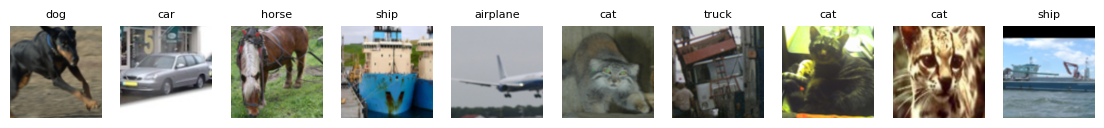

In [8]:
def denorm_STL10(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_STL10(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [9]:
INPUT_DIM = 96 * 96 * 3
NUM_CLASSES = 10

class MLP(nn.Module):
    def __init__(self, input_dim: int, num_classes: int, hidden1: int = 1024, hidden2: int = 512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B,C,H,W) -> (B, C*H*W)
        x = x.view(x.size(0), -1)
        return self.net(x)

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

mlp = MLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)
print(mlp)
print("Trainable params:", count_params(mlp))

MLP(
  (net): Sequential(
    (0): Linear(in_features=27648, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)
Trainable params: 28842506


In [10]:
def log_experiment(
    experiment_id: str,
    task: str,
    dataset: str,
    seed: int,
    model_summary: str,
    optimizer: str,
    lr: float,
    epochs_trained: int,
    best_val_accuracy: float = None,
    test_accuracy: float = None,
    precision: float = None,
    recall: float = None,
    mean_iou: float = None,
    notes: str = ""
):
    """
    Минимальная функция логирования экспериментов в runs.csv
    """
    experiment_data = {
        'experiment_id': experiment_id,
        'task': task,
        'dataset': dataset,
        'seed': seed,
        'model_summary': model_summary,
        'optimizer': optimizer,
        'lr': lr,
        'epochs_trained': epochs_trained,
        'best_val_accuracy': best_val_accuracy,
        'test_accuracy': test_accuracy,
        'precision': precision,
        'recall': recall,
        'mean_iou': mean_iou,
        'notes': notes
    }
    
    runs_file = 'artifacts/runs.csv'
    if os.path.exists(runs_file):
        df_existing = pd.read_csv(runs_file)
        df_new = pd.DataFrame([experiment_data])
        df_final = pd.concat([df_existing, df_new], ignore_index=True)
    else:
        df_final = pd.DataFrame([experiment_data])
    
    # Сохраняем
    df_final.to_csv(runs_file, index=False)
    print(f"[{experiment_id}] Сохранено в runs.csv")
    
    return df_final

In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 224x224 -> 224x224
            nn.ReLU(), nn.MaxPool2d(2),                   # -> 112x112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 112x112 -> 112x112  
            nn.ReLU(), nn.MaxPool2d(2),                   # -> 56x56

            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 56x56 -> 56x56
            nn.ReLU(), nn.MaxPool2d(2),                   # -> 28x28

            nn.Conv2d(128, 256, kernel_size=3, padding=1),# 28x28 -> 28x28
            nn.ReLU(), nn.MaxPool2d(2),                   # -> 14x14

            nn.Conv2d(256, 512, kernel_size=3, padding=1),# 14x14 -> 14x14
            nn.ReLU(), nn.MaxPool2d(2),                   # -> 7x7
        )

        # 512 * 7 * 7 = 25088
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 1024),  # 25088 → 1024
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes),
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x


cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (

In [12]:

def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

In [13]:
# Быстрый sanity-check по shape
with torch.no_grad():
    x_test = torch.randn(2, 3, 224, 224).to(DEVICE)
    print(f"Test: {x_test.shape} → {cnn(x_test).shape}")
    print(f"After features: {cnn.features(x_test).view(2, -1).shape}")


Test: torch.Size([2, 3, 224, 224]) → torch.Size([2, 10])
After features: torch.Size([2, 25088])



Experiment CNN_simple | lr=0.001 weight_decay=0.0 epochs=5
Trainable params: 27269962
Epoch 01/5 | train loss 2.0757, acc 0.237 | val loss 1.7793, acc 0.329 | 75.1s
Epoch 02/5 | train loss 1.7280, acc 0.346 | val loss 1.5881, acc 0.376 | 74.2s
Epoch 03/5 | train loss 1.5783, acc 0.404 | val loss 1.4646, acc 0.446 | 74.4s
Epoch 04/5 | train loss 1.4617, acc 0.438 | val loss 1.4622, acc 0.438 | 74.7s
Epoch 05/5 | train loss 1.4197, acc 0.464 | val loss 1.3727, acc 0.486 | 73.6s


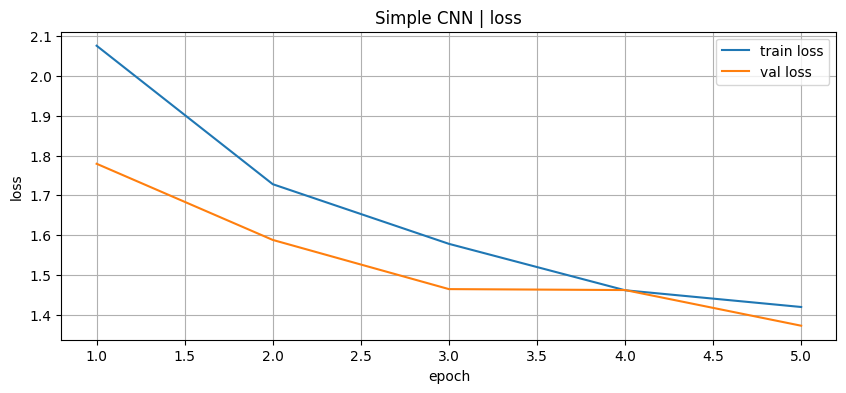

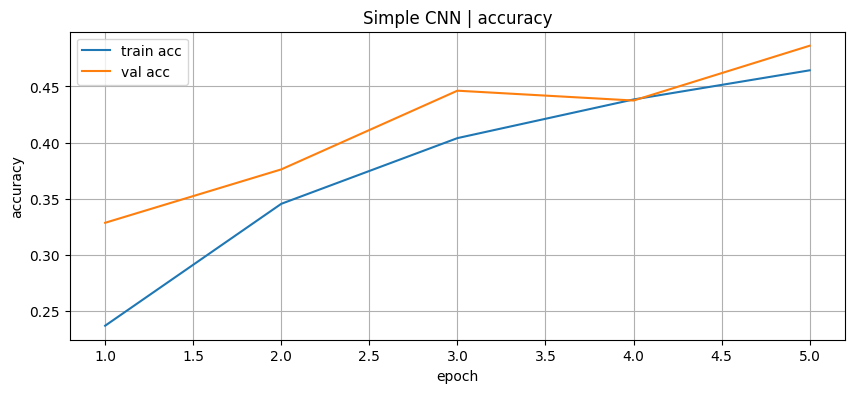

Best val acc: 0.486


In [14]:
criterion = nn.CrossEntropyLoss()

def run_experiment(exp_id: str, model: nn.Module, lr: float = 1e-3, weight_decay: float = 0.0, epochs: int = EPOCHS):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print("\n" + "=" * 80)
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_params(model))

    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    return {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}

res_cnn = run_experiment("CNN_simple", SimpleCNN(NUM_CLASSES), lr=1e-3, epochs=EPOCHS)
plot_history(res_cnn["history"], title="Simple CNN")
print(f"Best val acc: {res_cnn['best_val_acc']:.3f}")

In [15]:
import torchvision.transforms as transforms

# C1: базовая без аугментаций (как было)
base_tf = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# C2: с аугментациями
train_tf = transforms.Compose([
    transforms.Resize(112),                    # padding
    transforms.RandomResizedCrop(96, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),  # твои ImageNet stats
])

eval_tf = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Теперь используем разные transforms для train/val
def make_loaders_aug(
    ds_train_aug, ds_train_eval, ds_test, 
    batch_size: int = 64, fast_mode: bool = True
):
    # Разделяем train на train/val
    n_total = len(ds_train_aug)
    n_val = int(n_total * 0.2)
    
    indices = list(range(n_total))
    import numpy as np
    np.random.seed(42)
    np.random.shuffle(indices)
    
    train_idx = indices[n_val:]
    val_idx = indices[:n_val]
    
    # Применяем разные transforms!
    ds_train = torch.utils.data.Subset(ds_train_aug, train_idx)      # с аугментациями
    ds_val = torch.utils.data.Subset(ds_train_eval, val_idx)         # без аугментаций
    
    if fast_mode:
        train_idx2 = np.random.choice(len(ds_train), size=2000, replace=False)
        val_idx2 = np.random.choice(len(ds_val), size=500, replace=False)
        test_idx2 = np.random.choice(len(ds_test), size=1000, replace=False)
        
        ds_train = torch.utils.data.Subset(ds_train, train_idx2)
        ds_val = torch.utils.data.Subset(ds_val, val_idx2)
        ds_test_small = torch.utils.data.Subset(ds_test, test_idx2)
    else:
        ds_test_small = ds_test
    
    train_loader = torch.utils.data.DataLoader(
        ds_train, batch_size=batch_size, shuffle=True, num_workers=2
    )
    val_loader = torch.utils.data.DataLoader(
        ds_val, batch_size=batch_size, shuffle=False, num_workers=2
    )
    test_loader = torch.utils.data.DataLoader(
        ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2
    )
    
    return train_loader, val_loader, test_loader

# Создаём CNN (архитектура не меняется)
cnn_aug = SimpleCNN(num_classes=10).to(DEVICE)
print("C2 simple-cnn-aug:")
print(cnn_aug)
print("Trainable params:", count_trainable_params(cnn_aug))

# Загружаем данные с аугментациями
train_loader_aug, val_loader_aug, test_loader_aug = make_loaders_aug(
    ds_train_aug, ds_train_eval, ds_test
)

# Проверяем
x, y = next(iter(train_loader_aug))
print(f"Batch shape: {x.shape}, labels: {y.shape}")


C2 simple-cnn-aug:
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1


Experiment CNN_aug_96 | lr=0.001 weight_decay=0.0 epochs=5
Trainable params: 27269962
Epoch 01/5 | train loss 2.1097, acc 0.204 | val loss 1.8209, acc 0.292 | 73.8s
Epoch 02/5 | train loss 1.7411, acc 0.333 | val loss 1.6301, acc 0.394 | 75.2s
Epoch 03/5 | train loss 1.6258, acc 0.373 | val loss 1.5522, acc 0.404 | 74.4s
Epoch 04/5 | train loss 1.5489, acc 0.414 | val loss 1.4306, acc 0.445 | 75.6s
Epoch 05/5 | train loss 1.4546, acc 0.448 | val loss 1.4295, acc 0.435 | 74.4s


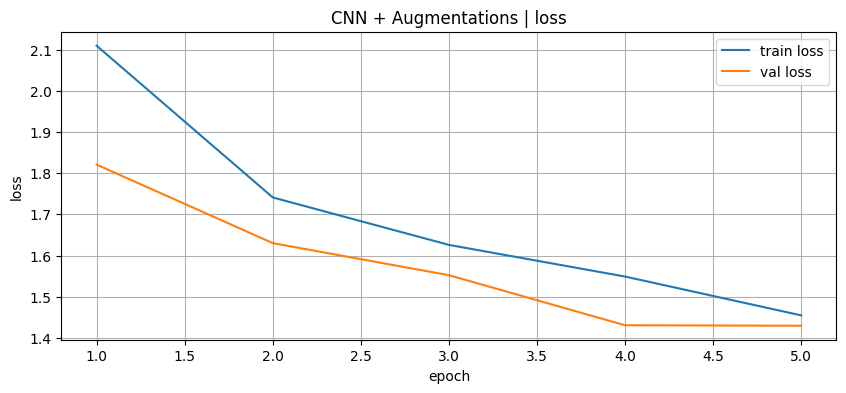

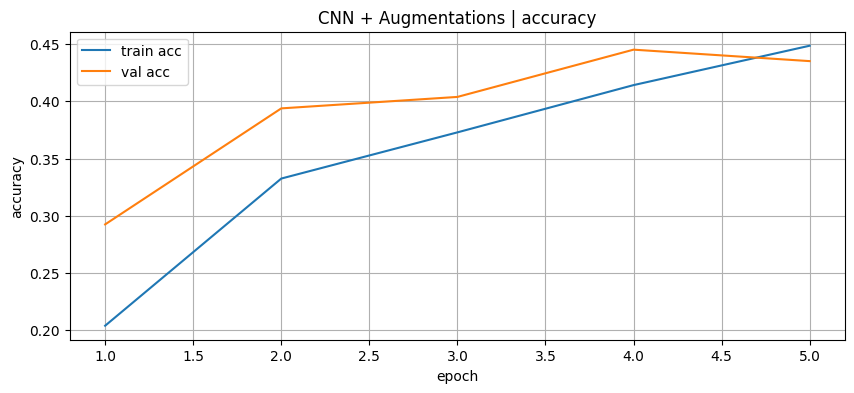

Best val acc: 0.445


In [16]:
# C2: CNN + аугментации
res_cnn_aug = run_experiment(
    "CNN_aug_96", 
    SimpleCNN(NUM_CLASSES), 
    lr=1e-3, 
    epochs=EPOCHS
)
plot_history(res_cnn_aug["history"], title="CNN + Augmentations")
print(f"Best val acc: {res_cnn_aug['best_val_acc']:.3f}")

Trainable params (head-only): 5130

Phase 1: head-only training
Epoch 01/4 | train loss 1.2163, acc 0.690 | val loss 0.5285, acc 0.909 | 55.9s
Epoch 02/4 | train loss 0.4605, acc 0.907 | val loss 0.3268, acc 0.932 | 56.7s
Epoch 03/4 | train loss 0.3274, acc 0.931 | val loss 0.2599, acc 0.935 | 56.2s
Epoch 04/4 | train loss 0.2865, acc 0.928 | val loss 0.2320, acc 0.938 | 56.2s


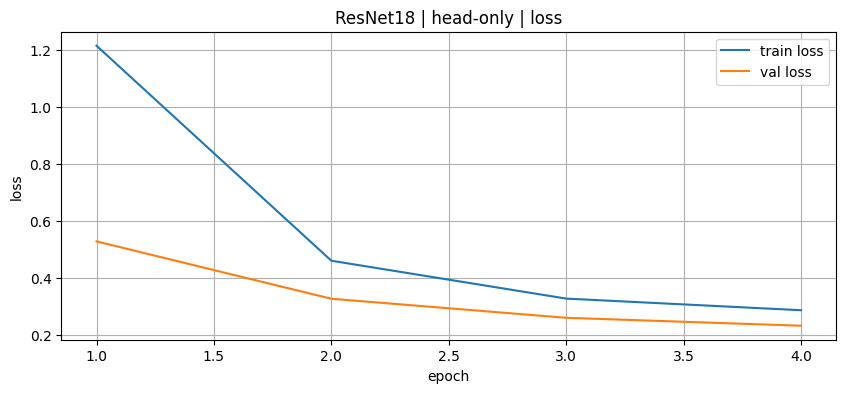

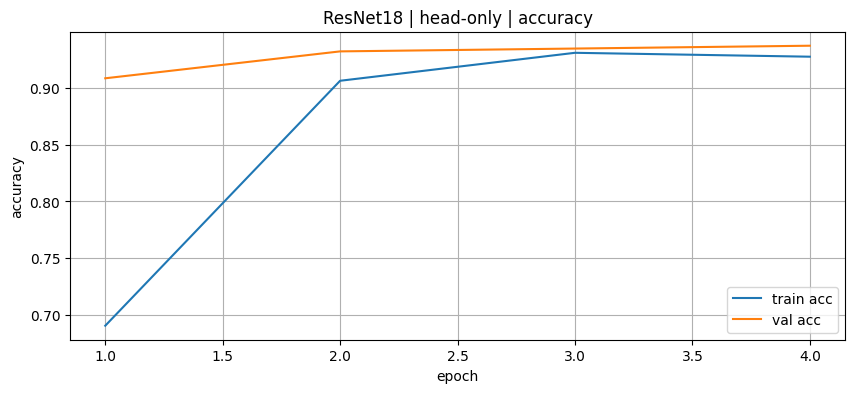

In [17]:
criterion = nn.CrossEntropyLoss()

model_head = build_resnet18(num_classes=10, weights=weights).to(DEVICE)

# freeze всё
set_requires_grad(model_head, False)
# размораживаем только голову
set_requires_grad(model_head.fc, True)

print("Trainable params (head-only):", count_trainable_params(model_head))

optimizer_head = torch.optim.Adam(model_head.fc.parameters(), lr=1e-3)

print("\n" + "=" * 80)
print("Phase 1: head-only training")
hist_head = fit(model_head, train_loader, val_loader, optimizer_head, criterion, epochs=EPOCHS_HEAD, verbose=True)
plot_history(hist_head, title="ResNet18 | head-only")

Trainable params (layer4+fc): 8398858

Phase 2: fine-tuning layer4 + fc
Epoch 01/4 | train loss 0.2282, acc 0.928 | val loss 0.1689, acc 0.940 | 70.9s
Epoch 02/4 | train loss 0.0930, acc 0.970 | val loss 0.1392, acc 0.960 | 69.5s
Epoch 03/4 | train loss 0.0505, acc 0.986 | val loss 0.1237, acc 0.960 | 68.1s
Epoch 04/4 | train loss 0.0377, acc 0.989 | val loss 0.1358, acc 0.956 | 70.5s


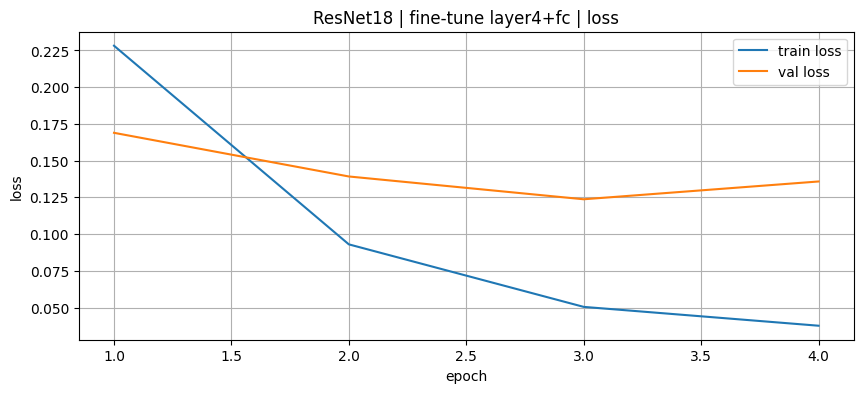

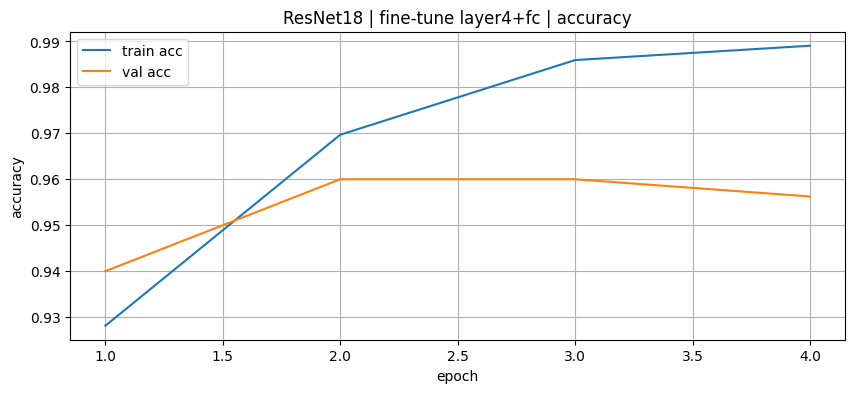

In [18]:
# размораживаем layer4 и fc
set_requires_grad(model_head.layer4, True)
set_requires_grad(model_head.fc, True)

print("Trainable params (layer4+fc):", count_trainable_params(model_head))

# param groups: backbone меньше, head больше
params = [
    {"params": model_head.layer4.parameters(), "lr": 1e-4},
    {"params": model_head.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("\n" + "=" * 80)
print("Phase 2: fine-tuning layer4 + fc")
hist_ft = fit(model_head, train_loader, val_loader, optimizer_ft, criterion, epochs=EPOCHS_FT, verbose=True)
plot_history(hist_ft, title="ResNet18 | fine-tune layer4+fc")

B часть

In [19]:
@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

test_acc = accuracy_on_loader(model_head, test_loader)
print("Test acc:", round(test_acc, 4))

Test acc: 0.942


In [20]:
# 5) Модель: DeepLabV3 (COCO-with-VOC-labels) + поиск индекса класса "PET"

import torchvision
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model = deeplabv3_resnet50(weights=weights)
model.to(DEVICE)
model.eval()

categories = weights.meta["categories"]
print("Доступные классы:", categories[:10], "..." if len(categories) > 10 else "")

CAT_IDX = categories.index("cat")
DOG_IDX = categories.index("dog")
PET_IDX = min(CAT_IDX, DOG_IDX)  # Используем первый из них для унификации
PET_CLASSES = [CAT_IDX, DOG_IDX]
print("num_classes:", len(categories))
print("CAT_IDX:", CAT_IDX)
print("DOG_IDX:", DOG_IDX)
print("PET_IDX (используемый):", PET_IDX)

# Трансформации, соответствующие весам
preprocess = weights.transforms()
preprocess

Доступные классы: ['__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair'] ...
num_classes: 21
CAT_IDX: 8
DOG_IDX: 12
PET_IDX (используемый): 8


SemanticSegmentation(
    resize_size=[520]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [21]:
# 3) Данные: Oxford-IIIT Pet (download/unzip при необходимости)

# Трансформации для изображений
img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Трансформации для масок (только resize и ToTensor, без нормализации)
mask_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor(),
])

# Загрузка обучающей части (исправлено: split_mask -> target_types)
dataset = torchvision.datasets.OxfordIIITPet(
    root='./data',
    split='trainval',       # trainval = train + val (7390 изображений)
    target_types='segmentation', # параметр для загрузки масок
    download=True,         
    transform=img_transform,
    target_transform=mask_transform,
)

# Загрузка тестовой части
test_dataset = torchvision.datasets.OxfordIIITPet(
    root='./data',
    split='test',           # test set (3669 изображений)
    target_types='segmentation', # параметр для загрузки масок
    download=True,
    transform=img_transform,
    target_transform=mask_transform,
)

        
len(dataset), dataset[0][0].size, dataset[0][1].shape

(3680, <function Tensor.size>, torch.Size([1, 224, 224]))

In [22]:
print(f"Train dataset size: {len(dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

img, mask = dataset[0]
print(f"Image shape: {img.shape}")  # [3, 224, 224]
print(f"Mask shape: {mask.shape}")  # [1, 224, 224]

Train dataset size: 3680
Test dataset size: 3669
Image shape: torch.Size([3, 224, 224])
Mask shape: torch.Size([1, 224, 224])


In [23]:
@torch.no_grad()
def predict_pet_mask(img_pil: Image.Image, confidence_threshold=0.5):
    x = preprocess(img_pil).unsqueeze(0).to(DEVICE)
    out = model(x)["out"][0]           # [21, H, W]
    probs = torch.softmax(out, dim=0)   # [21, H, W]
    # Суммируем вероятности для классов кошки и собаки
    pet_probs = probs[PET_CLASSES].sum(dim=0)  # [H, W]
    pet_mask = pet_probs > confidence_threshold
    return pet_mask.to(torch.uint8).cpu(), x.shape[-2:]

def iou_binary(pred: torch.Tensor, gt: torch.Tensor) -> float:
    pred = pred.bool()
    gt = gt.bool()
    inter = (pred & gt).sum().item()
    union = (pred | gt).sum().item()
    return float(inter / (union + 1e-9))

@torch.no_grad()
def eval_subset(indices: List[int], threshold=0.5 ) -> Dict[str, float]:
    ious = []
    for idx in indices:
        img_pil, gt_np = dataset[idx]
        
        # Предсказание
        pred_mask, (h, w) = predict_pet_mask(img_pil, confidence_threshold = threshold)
        
        # FIX: Конвертируем тензор в numpy и исправляем форму
        if isinstance(gt_np, torch.Tensor):
            gt_np = gt_np.numpy()
        
        # gt_np имеет форму (1, H, W) - нужно (H, W) для PIL
        if gt_np.ndim == 3 and gt_np.shape[0] == 1:
            gt_np = gt_np[0]  # Убираем размерность канала
        
        # Теперь gt_np имеет форму (H, W)
        gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
        gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)
        
        ious.append(iou_binary(pred_mask, gt_mask))
    
    return {
        "n": float(len(ious)),
        "mean_IoU": float(np.mean(ious)),
        "median_IoU": float(np.median(ious)),
        "min_IoU": float(np.min(ious)),
        "max_IoU": float(np.max(ious)),
    }

Baseline (threshold=0.5):
{'n': 36.0, 'mean_IoU': 0.029645381328073525, 'median_IoU': 7.396449704141985e-06, 'min_IoU': 0.0, 'max_IoU': 0.33313979289940704}

Alternative threshold 0.3:
{'n': 36.0, 'mean_IoU': 0.05166861850756063, 'median_IoU': 0.004132766272189334, 'min_IoU': 0.0, 'max_IoU': 0.5060613905325425}
Сохранено в artifacts/figures/segmentation_examples.png


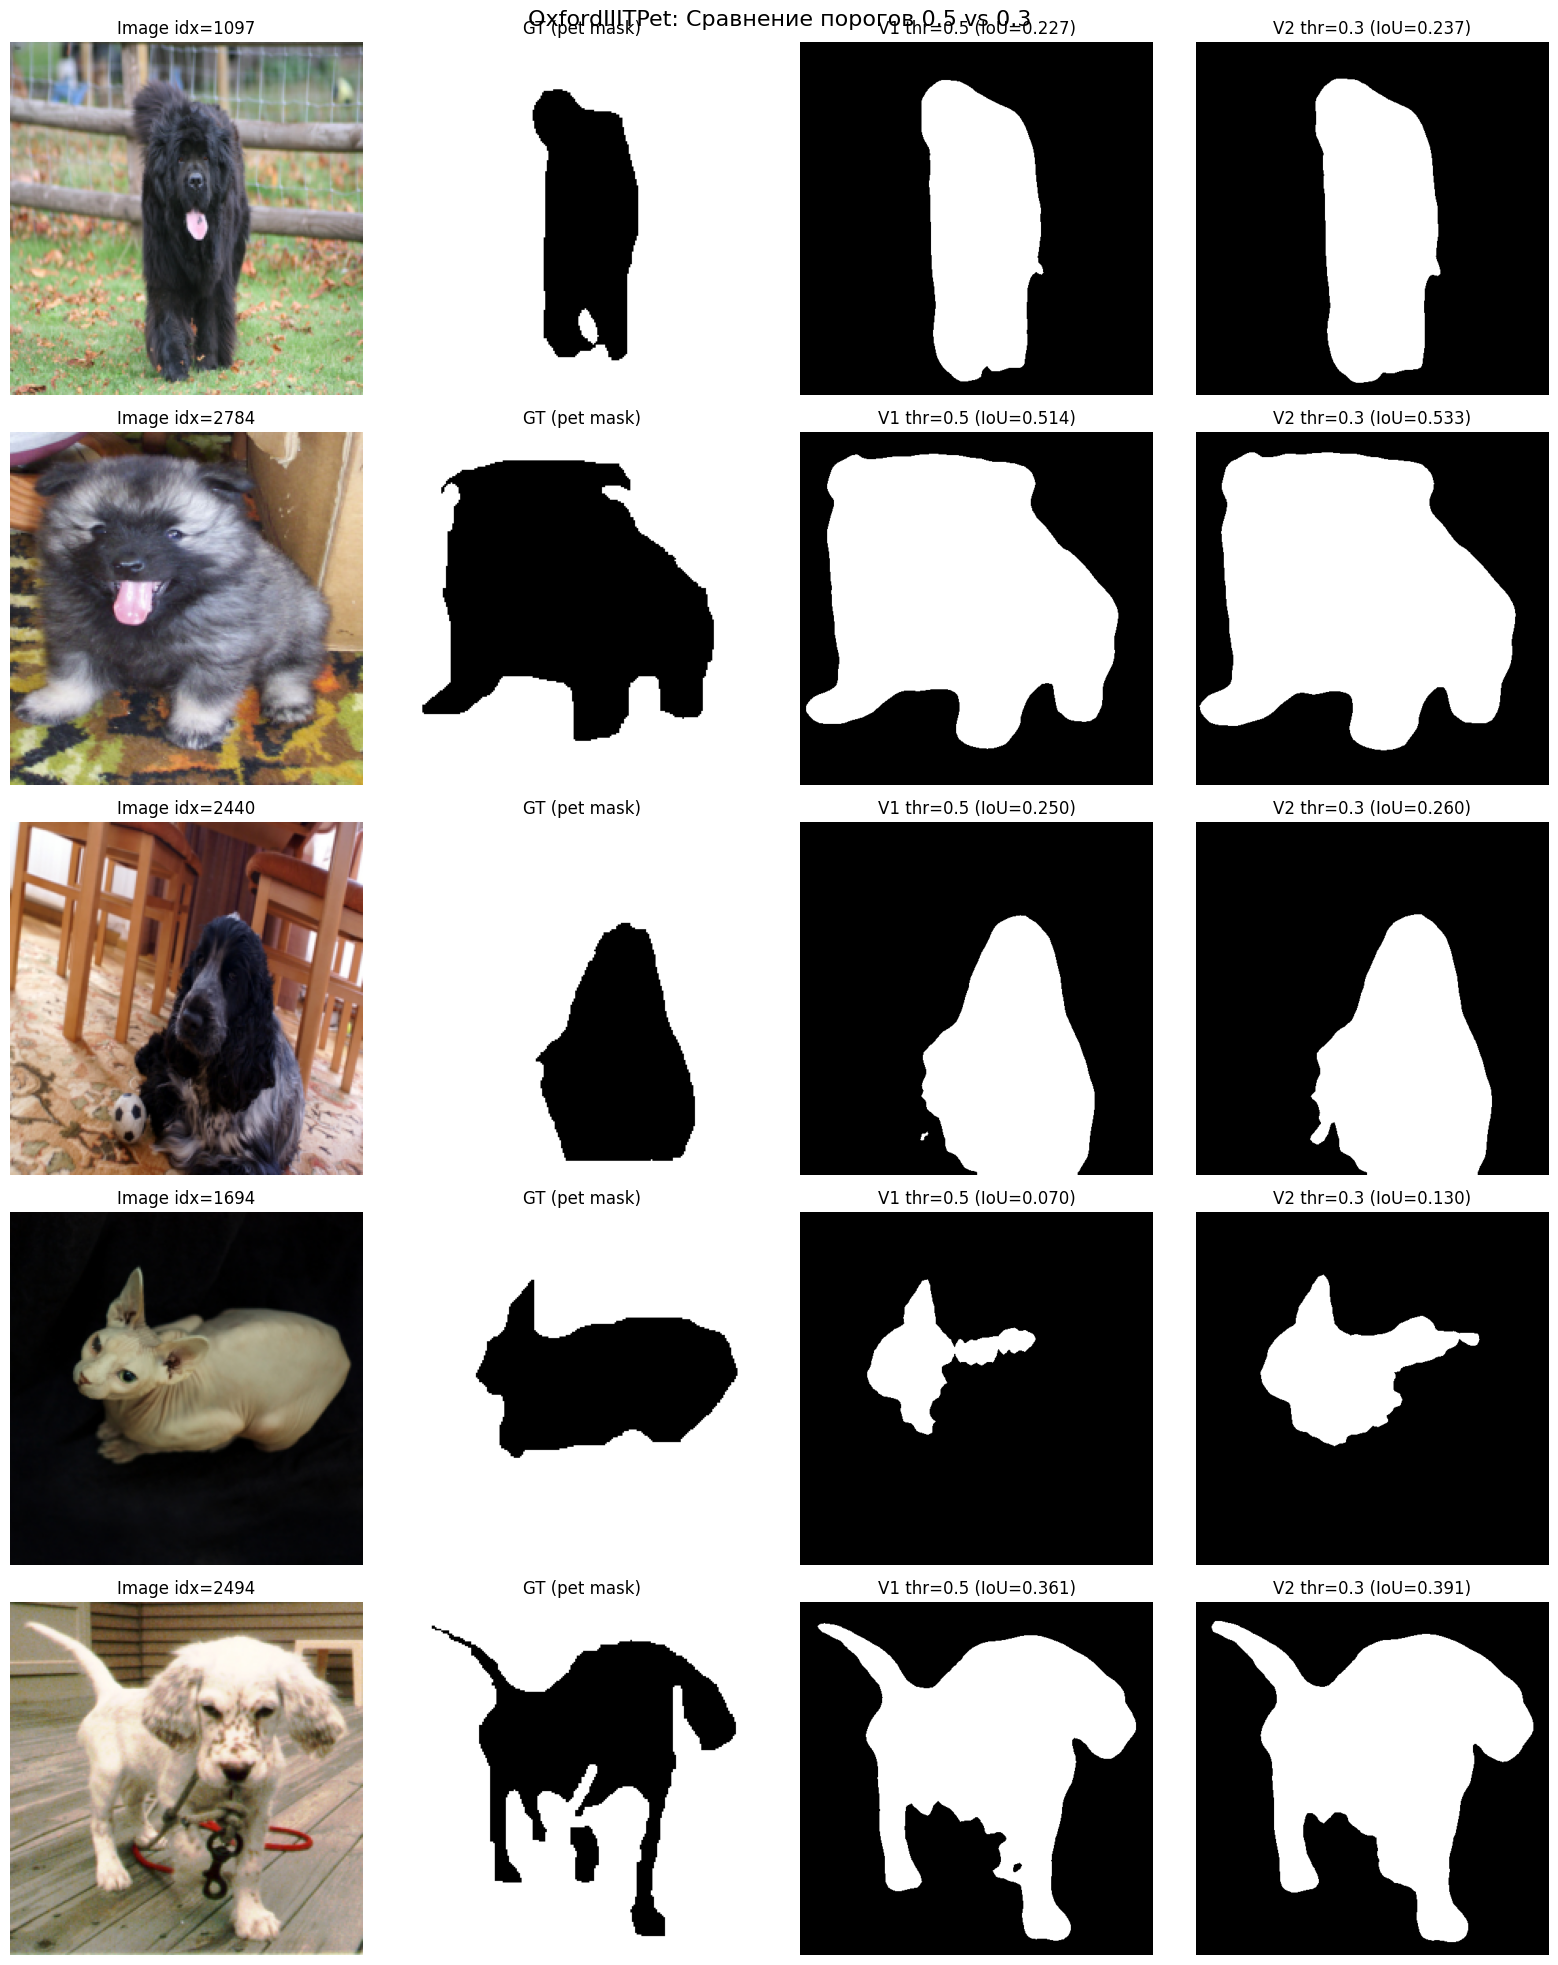


--- Summary ---
Threshold 0.5  -> mean IoU: 0.0296
Threshold 0.3  -> mean IoU: 0.0517


In [24]:
import torchvision.transforms.functional as F

# ---------- Визуализация сравнения порогов (0.5 vs 0.3) с выводом IoU ----------
def visualize_threshold_comparison_with_save(indices, thresholds=[0.5, 0.3], 
                                              save_path='artifacts/figures/segmentation_examples.png'):
    """
    Для каждого изображения показывает: исходное изображение, GT,
    предсказание с порогом 0.5 и предсказание с порогом 0.3.
    """
    n = min(len(indices), len(dataset))
    fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
    
    if n == 1:
        axes = np.expand_dims(axes, axis=0)
    
    for row, idx in enumerate(indices):
        img_tensor, gt_np = dataset[idx]
        
        # ========== Конвертация изображения для отображения ==========
        if isinstance(img_tensor, torch.Tensor):
            img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
            img_np = img_np * 0.5 + 0.5  # Denormalize
            img_np = np.clip(img_np, 0, 1)
            img_pil = Image.fromarray((img_np * 255).astype(np.uint8))
        else:
            img_pil = img_tensor
        
        # ========== Предсказания с разными порогами ==========
        pred_mask_v1, (h, w) = predict_pet_mask(img_pil, confidence_threshold=0.5)
        pred_mask_v2, _ = predict_pet_mask(img_pil, confidence_threshold=0.3)
        
        # ========== Конвертация GT маски ==========
        if isinstance(gt_np, torch.Tensor):
            gt_np = gt_np.cpu().numpy()
        if gt_np.ndim == 3 and gt_np.shape[0] == 1:
            gt_np = gt_np.squeeze(0)
        
        # GT resize to model space
        gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
        gt_rs = resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)
        
        # ========== Вычисление IoU ==========
        iou_v1 = iou_binary(pred_mask_v1, gt_mask)
        iou_v2 = iou_binary(pred_mask_v2, gt_mask)
        
        # ========== Колонка 1: Исходное изображение ==========
        axes[row, 0].imshow(img_pil)
        axes[row, 0].set_title(f"Image idx={idx}")
        axes[row, 0].axis("off")
        
        # ========== Колонка 2: GT маска ==========
        if isinstance(gt_np, torch.Tensor):
            gt_np = gt_np.cpu().numpy()
        if gt_np.ndim == 3 and gt_np.shape[0] == 1:
            gt_np = gt_np.squeeze(0)
        
        # Бинаризация: питомец = класс 2 → значение ~2/255 после ToTensor
        # Порог между 1/255 (фон) и 2/255 (питомец)
        gt_binary = (gt_np > 1.5/255).astype(np.float32)  # 0 или 1
        
        axes[row, 1].imshow(gt_binary, cmap='gray', vmin=0, vmax=1)
        axes[row, 1].set_title("GT (pet mask)")
        axes[row, 1].axis("off")
        
        # ========== Колонка 3: V1 предсказание (threshold=0.5) ==========
        axes[row, 2].imshow(pred_mask_v1.numpy(), cmap="gray", vmin=0, vmax=1)
        axes[row, 2].set_title(f"V1 thr=0.5 (IoU={iou_v1:.3f})")
        axes[row, 2].axis("off")
        
        # ========== Колонка 4: V2 предсказание (threshold=0.3) ==========
        axes[row, 3].imshow(pred_mask_v2.numpy(), cmap="gray", vmin=0, vmax=1)
        axes[row, 3].set_title(f"V2 thr=0.3 (IoU={iou_v2:.3f})")
        axes[row, 3].axis("off")
    
    plt.suptitle("OxfordIIITPet: Сравнение порогов 0.5 vs 0.3", fontsize=16, y=0.98)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Сохранено в {save_path}")
    plt.show()

# ---------- Выбор тестовых индексов ----------
if cfg.fast_mode:
    test_indices = list(range(len(dataset)//100))
else:
    test_indices = list(range(len(dataset)))

# ---------- Базовый порог 0.5 ----------
print("Baseline (threshold=0.5):")
base_metrics = eval_subset(test_indices)
print(base_metrics)

# ---------- Альтернативный порог 0.3 ----------
print("\nAlternative threshold 0.3:")
alt_metrics = eval_subset(test_indices, threshold=0.3)
print(alt_metrics)

# ---------- Визуализация сравнения ----------
eval_indices = list(range(len(dataset)))
np.random.seed(42)
np.random.shuffle(eval_indices)
visual_indices = eval_indices[:5]

# Вызываем функцию визуализации
visualize_threshold_comparison_with_save(
    visual_indices, 
    thresholds=[0.5, 0.3],
    save_path='artifacts/figures/segmentation_examples.png'
)

# ---------- Итоговое сравнение среднего IoU ----------
print("\n--- Summary ---")
print(f"Threshold 0.5  -> mean IoU: {base_metrics['mean_IoU']:.4f}")
print(f"Threshold 0.3  -> mean IoU: {alt_metrics['mean_IoU']:.4f}")

In [25]:
log_experiment(
    experiment_id='C1',
    task='classification',
    dataset='STL10',
    seed=RANDOM_STATE,
    model_summary='SimpleCNN (3 conv + 2 fc)',
    optimizer='Adam',
    lr=0.001,
    epochs_trained=len(res_cnn['history']['val_acc']) if 'res_cnn' in locals() else None,
    best_val_accuracy=res_cnn['best_val_acc'] if 'res_cnn' in locals() else None,
    notes='простая CNN без аугментаций'
)


log_experiment(
    experiment_id='C2',
    task='classification',
    dataset='STL10',
    seed=RANDOM_STATE,
    model_summary='SimpleCNN (3 conv + 2 fc)',
    optimizer='Adam',
    lr=0.001,
    epochs_trained=len(res_cnn_aug['history']['val_acc']),
    best_val_accuracy=res_cnn_aug['best_val_acc'],
    notes='CNN с аугментациями'
)


log_experiment(
    experiment_id='C3',
    task='classification',
    dataset='STL10',
    seed=RANDOM_STATE,
    model_summary='ResNet18 (pretrained)',
    optimizer='Adam',
    lr=1e-3,
    epochs_trained=len(hist_head['val_acc']),
    best_val_accuracy=max(hist_head['val_acc']),
    notes='только обучение головы (fc)'
)


log_experiment(
    experiment_id='C4',
    task='classification',
    dataset='STL10',
    seed=RANDOM_STATE,
    model_summary='ResNet18 (pretrained), layer4+fc',
    optimizer='Adam',
    lr=1e-4,  # условно, для layer4
    epochs_trained=len(hist_ft['val_acc']),
    best_val_accuracy=max(hist_ft['val_acc']),
    test_accuracy=test_acc,
    notes='fine-tuning layer4 и fc'
)

[C1] Сохранено в runs.csv
[C2] Сохранено в runs.csv
[C3] Сохранено в runs.csv
[C4] Сохранено в runs.csv


C:\Users\Mi\AppData\Local\Temp\ipykernel_9072\4261354937.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_final = pd.concat([df_existing, df_new], ignore_index=True)
C:\Users\Mi\AppData\Local\Temp\ipykernel_9072\4261354937.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_final = pd.concat([df_existing, df_new], ignore_index=True)
C:\Users\Mi\AppData\Local\Temp\ipykernel_9072\4261354937.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is dep

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,SimpleCNN (3 conv + 2 fc),Adam,0.0010,5.0,0.48625,0.490,NaN,NaN,NaN,простая CNN без аугментаций
1,C2,classification,STL10,42,SimpleCNN (3 conv + 2 fc),Adam,0.0010,5.0,0.44500,0.463,NaN,NaN,NaN,CNN с аугментациями
2,C3,classification,STL10,42,ResNet18 (pretrained),Adam,0.0010,4.0,0.93750,0.947,NaN,NaN,NaN,только обучение головы (fc)
3,C4,classification,STL10,42,"ResNet18 (pretrained), layer4+fc",Adam,0.0001,4.0,0.95125,0.927,NaN,NaN,NaN,fine-tuning layer4 и fc
4,V1,segmentation,OxfordIIITPet,42,DeepLabV3_ResNet50 (COCO),-,NaN,NaN,NaN,NaN,NaN,NaN,0.005659,"порог бинаризации 0.5, бинарная маска (cat+dog)"
5,V2,segmentation,OxfordIIITPet,42,DeepLabV3_ResNet50 (COCO),-,NaN,NaN,NaN,NaN,NaN,NaN,0.010228,порог бинаризации 0.3
6,C1,classification,STL10,42,SimpleCNN (3 conv + 2 fc),Adam,0.0010,5.0,0.48625,NaN,NaN,NaN,NaN,простая CNN без аугментаций
7,C2,classification,STL10,42,SimpleCNN (3 conv + 2 fc),Adam,0.0010,5.0,0.44500,NaN,NaN,NaN,NaN,CNN с аугментациями
8,C3,classification,STL10,42,ResNet18 (pretrained),Adam,0.0010,4.0,0.93750,NaN,NaN,NaN,NaN,только обучение головы (fc)
9,C4,classification,STL10,42,"ResNet18 (pretrained), layer4+fc",Adam,0.0001,4.0,0.96000,0.942,NaN,NaN,NaN,fine-tuning layer4 и fc


In [26]:
if 'base_metrics' in locals():
    log_experiment(
        experiment_id='V1',
        task='segmentation',
        dataset='OxfordIIITPet',
        seed=RANDOM_STATE,
        model_summary='DeepLabV3_ResNet50 (COCO)',
        optimizer='-',
        lr=None,
        epochs_trained=None,
        mean_iou=base_metrics['mean_IoU'],
        notes='порог бинаризации 0.5, бинарная маска (cat+dog)'
    )

[V1] Сохранено в runs.csv


C:\Users\Mi\AppData\Local\Temp\ipykernel_9072\4261354937.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_final = pd.concat([df_existing, df_new], ignore_index=True)


In [27]:
if 'alt_metrics' in locals():
    log_experiment(
        experiment_id='V2',
        task='segmentation',
        dataset='OxfordIIITPet',
        seed=RANDOM_STATE,
        model_summary='DeepLabV3_ResNet50 (COCO)',
        optimizer='-',
        lr=None,
        epochs_trained=None,
        mean_iou=alt_metrics['mean_IoU'],
        notes='порог бинаризации 0.3'
    )


[V2] Сохранено в runs.csv


C:\Users\Mi\AppData\Local\Temp\ipykernel_9072\4261354937.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_final = pd.concat([df_existing, df_new], ignore_index=True)


In [28]:
# Находим лучшую эпоху по validation accuracy
best_epoch_ft = np.argmax(hist_ft["val_acc"])
best_val_acc_ft = max(hist_ft["val_acc"])

# Сохраняем модель
torch.save({
    'model_state_dict': model_head.state_dict(),
    'best_val_acc': best_val_acc_ft,
    'best_epoch': best_epoch_ft,
    'test_acc': test_acc,
}, 'artifacts/best_classifier.pt')
print("Сохранено best_classifier.pt")

Сохранено best_classifier.pt


In [30]:
import json

best_config = {
    # Основные параметры
    "dataset": "STL10",
    "task": "classification", 
    "num_classes": 10,
    "architecture": "ResNet18",
    "pretrained": "IMAGENET" if weights else "None",
    
    # Обучение head-only
    "head_only_epochs": EPOCHS_HEAD,
    "head_optimizer": "Adam",
    "head_lr": 0.001,
    
    # Fine-tune
    "finetune_layers": "layer4+fc",
    "finetune_epochs": EPOCHS_FT,
    "finetune_optimizer": "Adam",
    "finetune_lr_layer4": 1e-4,
    "finetune_lr_fc": 1e-3,
    "weight_decay": 1e-4,
    
    # Метрики лучшей модели
    "best_val_accuracy": float(best_val_acc_ft),
    "test_accuracy": float(test_acc),
    "best_epoch": int(best_epoch_ft),
    
    # Воспроизводимость
    "seed": int(RANDOM_STATE),
    "device": str(DEVICE),
    
    "batch_size": 64,
    "transforms": "resnet_transform",  # стандартный STL10 transform
}

with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)


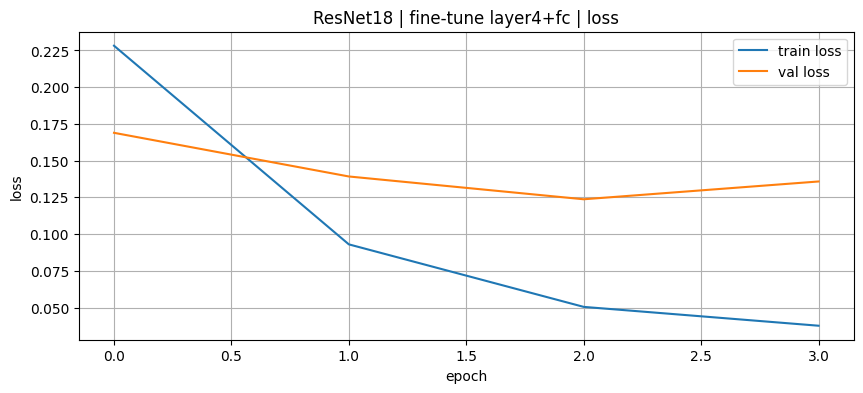

In [31]:
plt.figure(figsize=(10, 4))
plt.plot(hist_ft["train_loss"], label="train loss")
plt.plot(hist_ft["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("ResNet18 | fine-tune layer4+fc | loss")
plt.grid(True)
plt.legend()
plt.savefig('artifacts/figures/classification_curves_best.png')

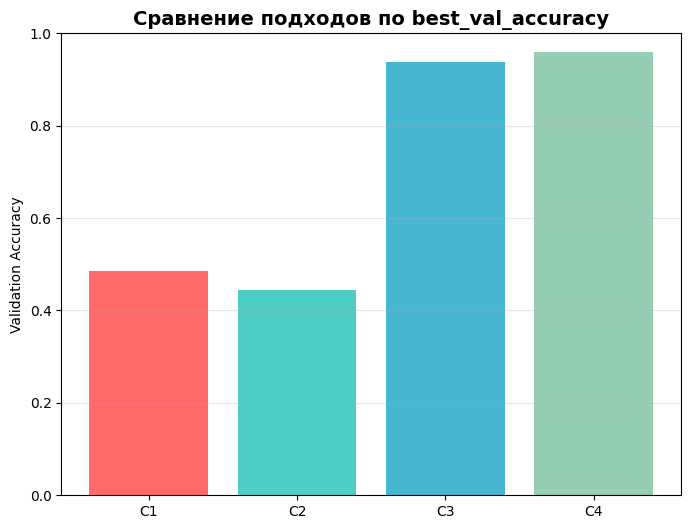

In [32]:
models = ['C1', 'C2', 'C3', 'C4']
accuracies = [
    res_cnn['best_val_acc'],
    res_cnn_aug['best_val_acc'],
    max(hist_head['val_acc']),
    best_val_acc_ft
]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
bars = ax.bar(models, accuracies, color=colors)
ax.set_title('Сравнение подходов по best_val_accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Validation Accuracy')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
plt.savefig('artifacts/figures/classification_compare.png')

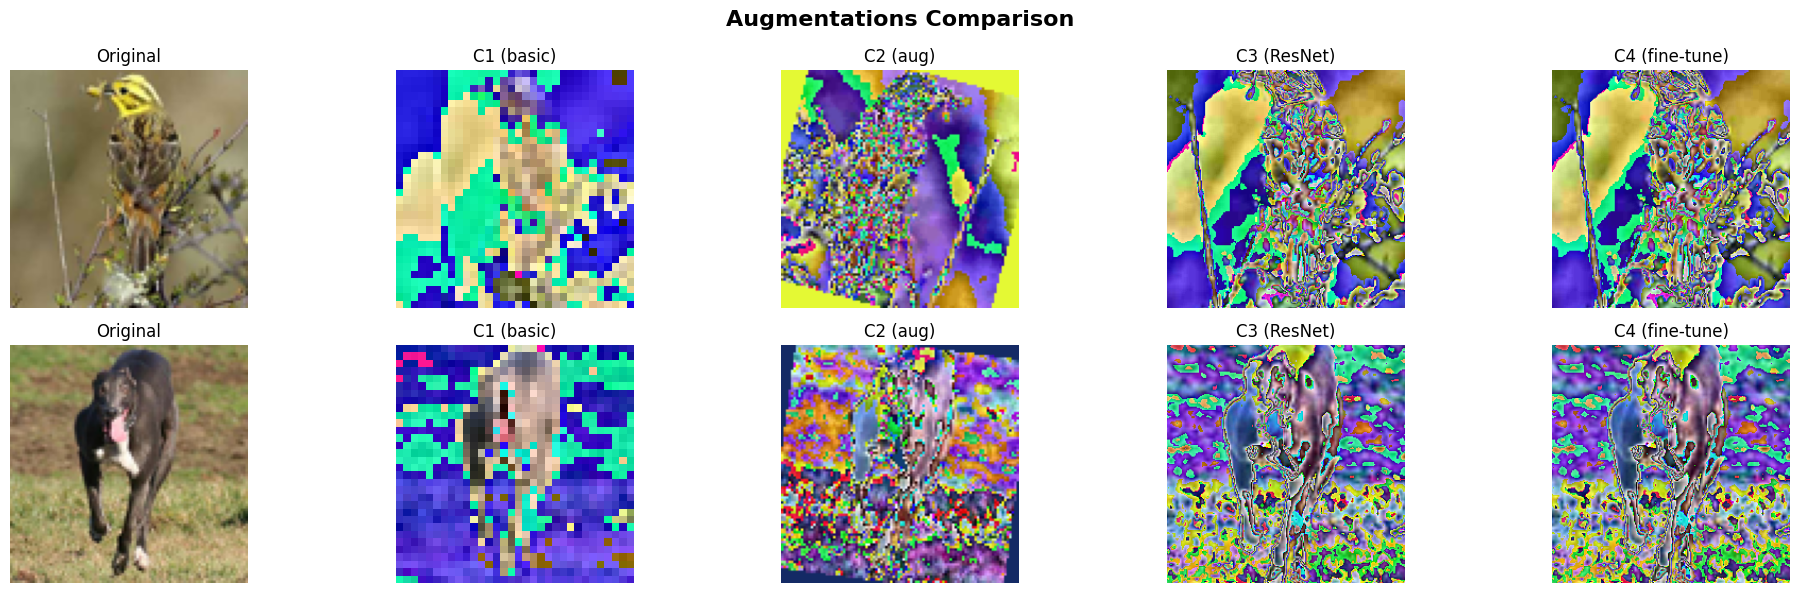

In [33]:
# Создаём словари с датасетами и трансформациями для отображения
# Для C1 используем ds_train_aug (но он с аугментациями) – нужно взять ds_train_eval (без аугментаций)
dataset_c1 = ds_train_eval  # базовый, без аугментаций
dataset_c2 = ds_train_aug   # с аугментациями (но в нём лежат Subset? лучше взять исходный)
# Для C3 (ResNet head-only) и C4 (fine-tune) используем те же датасеты, что и в обучении
# Используем ds_train_aug и ds_train_eval, но с разными трансформациями.
# Для простоты возьмём первые 2 изображения и применим нужные трансформации вручную.

# Трансформации для C1 (базовая) – стандартная для STL10 (resize 32x32)
basic_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
# Трансформации для C2 (аугментации) – как в train_tf
train_transform = transforms.Compose([
    transforms.Resize(112),
    transforms.RandomResizedCrop(96, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
# Трансформации для C3 и C4 (ResNet) – resnet_transform (preprocess)
resnet_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Берём 2 изображения из исходного датасета (не из Subset)
# Используем оригинальный ds_train_eval, который содержит полные данные
orig_dataset = torchvision.datasets.STL10(root=DATA_DIR, split='train', download=False, transform=None)
indices = [0, 1]  # два примера

fig, axes = plt.subplots(2, 5, figsize=(20, 6))  # 2 строки, 5 колонок: Original + C1, C2, C3, C4
for row, idx in enumerate(indices):
    img, _ = orig_dataset[idx]  # PIL Image
    # Колонка 0: оригинал
    axes[row, 0].imshow(img)
    axes[row, 0].set_title('Original')
    axes[row, 0].axis('off')
    
    # Колонка 1: C1 (базовая)
    img_c1 = basic_transform(img)
    img_c1 = F.to_pil_image(img_c1)
    axes[row, 1].imshow(img_c1)
    axes[row, 1].set_title('C1 (basic)')
    axes[row, 1].axis('off')
    
    # Колонка 2: C2 (аугментации)
    img_c2 = train_transform(img)
    img_c2 = F.to_pil_image(img_c2)
    axes[row, 2].imshow(img_c2)
    axes[row, 2].set_title('C2 (aug)')
    axes[row, 2].axis('off')
    
    # Колонка 3: C3 (ResNet head-only) – используем resnet_transform
    img_c3 = resnet_transform(img)
    img_c3 = F.to_pil_image(img_c3)
    axes[row, 3].imshow(img_c3)
    axes[row, 3].set_title('C3 (ResNet)')
    axes[row, 3].axis('off')
    
    # Колонка 4: C4 (fine-tune) – та же трансформация
    axes[row, 4].imshow(img_c3)
    axes[row, 4].set_title('C4 (fine-tune)')
    axes[row, 4].axis('off')

plt.suptitle('Augmentations Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/figures/augmentations_preview.png')

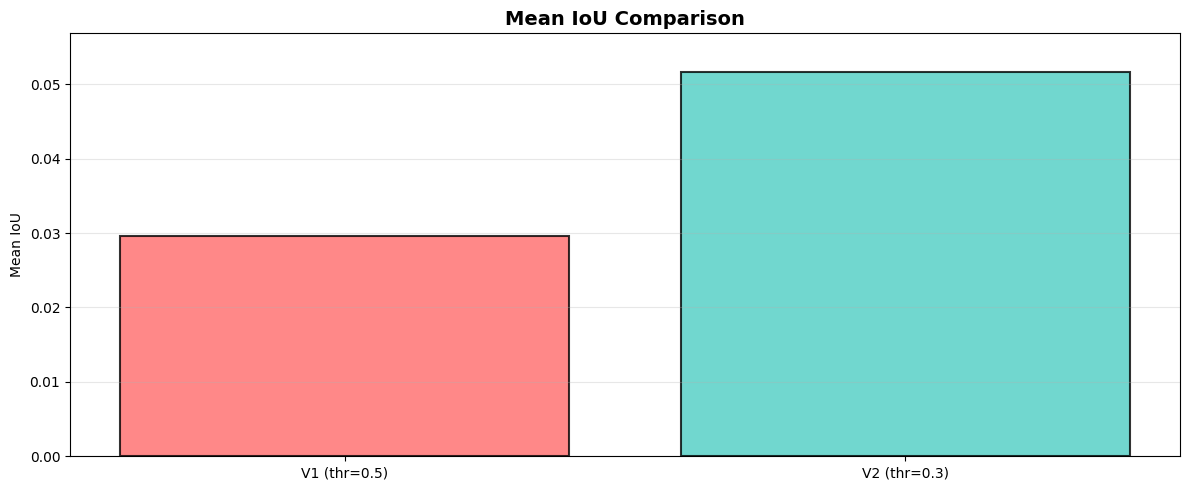

In [34]:
# ========== 6. Сохранение графика сравнения IoU для сегментации ==========
# У нас уже есть переменные base_metrics и alt_metrics из предыдущих ячеек
# Если нет – вычислим заново (на тот же тестовый набор)
if 'base_metrics' not in locals() or 'alt_metrics' not in locals():
    # Пересчитываем на тестовом подмножестве
    if cfg.fast_mode:
        eval_indices = list(range(len(dataset)//100))
    else:
        eval_indices = list(range(len(dataset)))
    base_metrics = eval_subset(eval_indices)
    alt_metrics = eval_subset(eval_indices, threshold=0.3)

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
categories = ['V1 (thr=0.5)', 'V2 (thr=0.3)']
mean_ious = [base_metrics['mean_IoU'], alt_metrics['mean_IoU']]

bars = ax.bar(categories, mean_ious, color=['#FF6B6B', '#4ECDC4'], 
               alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_title('Mean IoU Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean IoU')
ax.set_ylim(0, max(mean_ious)*1.1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('artifacts/figures/segmentation_metrics.png')